# 01 — OSM-Daten für Zürich laden

**Ziel:** Stadtgrenze und alle relevanten Points of Interest (POIs) per OSMnx aus OpenStreetMap holen, in einem GeoPackage ablegen und einen ersten Sichtcheck machen.

**Quellen:**
- OpenStreetMap via OSMnx → `ox.geocode_to_gdf`, `ox.features_from_polygon`
- siehe auch `docs/data_sources.md`

**Output:**
- `data/processed/zh_boundary.gpkg`
- `data/processed/zh_pois.gpkg` (alle Kategorien zusammengelegt)

## 1. Setup

Wir hängen das Projekt-`src`-Verzeichnis an den Pythonpfad, sodass wir das Paket `zh15min` importieren können.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')

from zh15min import config, osm
print('Projekt-Root:', ROOT)
print('Datenverzeichnis:', config.DATA_DIR)

Projekt-Root: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing
Datenverzeichnis: /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/data


## 2. Stadtgrenze Zürich laden

In [2]:
boundary = osm.city_boundary('Zürich, Switzerland')
boundary.to_file(config.PROCESSED_DIR / 'zh_boundary.gpkg', layer='boundary', driver='GPKG')
print(f'Stadtgrenze geladen: {len(boundary)} Polygon(e)')
boundary.head(2)

2026-05-08 01:21:17,975 | INFO | Lade Stadtgrenze für Zürich, Switzerland
2026-05-08 01:21:18,044 | INFO | Created 1 records


Stadtgrenze geladen: 1 Polygon(e)


,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((8.44801 47.38025, 8.44847 47.37967, ...",8.448006,47.320219,8.625441,47.434666,71510086,relation,1682248,47.374449,8.541042,boundary,administrative,16,0.746973,city,Zurich,"Zurich, District Zurich, Zurich, Switzerland"


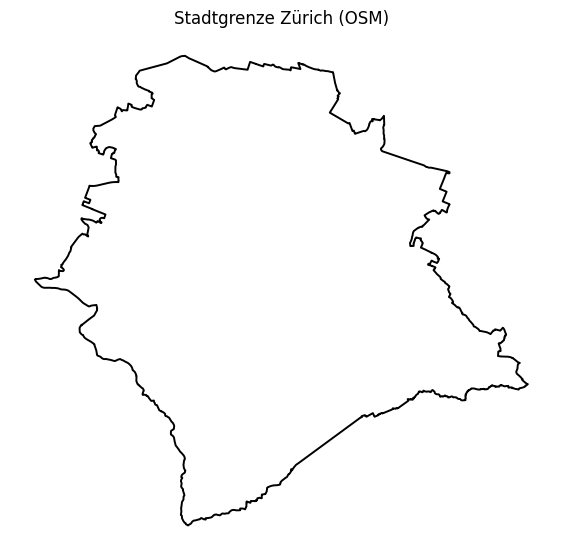

In [3]:
ax = boundary.plot(figsize=(7, 7), facecolor='none', edgecolor='black', linewidth=1.4)
ax.set_title('Stadtgrenze Zürich (OSM)', fontsize=12)
ax.set_axis_off();

## 3. POIs aller Kategorien laden

Die in `config.POI_CATEGORIES` definierten OSM-Tags werden Kategorie für Kategorie abgefragt. Polygon-POIs (z.B. Spitäler) werden auf ihren Schwerpunkt reduziert, damit wir später einheitlich mit Punkten rechnen können.

In [4]:
pois = osm.all_pois(boundary)
print(f'Insgesamt {len(pois):,} POIs')
pois.groupby('category').size().sort_values(ascending=False)

2026-05-08 01:21:18,189 | INFO | Lade POIs einkauf mit Tags {'shop': ['supermarket', 'convenience', 'bakery', 'butcher', 'greengrocer']}
2026-05-08 01:21:18,337 | INFO | Lade POIs bildung mit Tags {'amenity': ['school', 'kindergarten', 'library', 'university', 'college']}
2026-05-08 01:21:18,474 | INFO | Lade POIs gesundheit mit Tags {'amenity': ['pharmacy', 'doctors', 'clinic', 'hospital', 'dentist']}
2026-05-08 01:21:18,568 | INFO | Lade POIs erholung mit Tags {'leisure': ['park', 'playground', 'sports_centre', 'fitness_centre', 'garden']}
2026-05-08 01:21:18,848 | INFO | Lade POIs gastro mit Tags {'amenity': ['restaurant', 'cafe', 'bar', 'fast_food']}
2026-05-08 01:21:19,049 | INFO | Lade POIs oev mit Tags {'highway': ['bus_stop'], 'railway': ['tram_stop', 'station', 'halt'], 'public_transport': ['stop_position', 'platform']}


Insgesamt 8,092 POIs


category
erholung      2439
gastro        2126
oev           1858
bildung        773
einkauf        509
gesundheit     387
dtype: int64

In [5]:
# In ein GeoPackage schreiben — eine Layer pro Kategorie + 'all'
out_path = config.PROCESSED_DIR / 'zh_pois.gpkg'
if out_path.exists():
    out_path.unlink()

for cat, grp in pois.groupby('category'):
    grp.to_file(out_path, layer=cat, driver='GPKG')
pois.to_file(out_path, layer='all', driver='GPKG')
print('Gespeichert nach', out_path)

2026-05-08 01:21:19,336 | INFO | Created 773 records
2026-05-08 01:21:19,349 | INFO | Created 509 records
2026-05-08 01:21:19,361 | INFO | Created 2,439 records
2026-05-08 01:21:19,373 | INFO | Created 2,126 records
2026-05-08 01:21:19,382 | INFO | Created 387 records
2026-05-08 01:21:19,392 | INFO | Created 1,858 records
2026-05-08 01:21:19,416 | INFO | Created 8,092 records


Gespeichert nach /Users/memissanir/Documents/Claude/Projects/Einsatz von Geodaten in Marketing/data/processed/zh_pois.gpkg


## 4. Sichtcheck — POIs auf der Karte

Eine kleine, schnelle matplotlib-Karte zur Plausibilitätsprüfung. Die richtige Visualisierung folgt in Notebook 07.

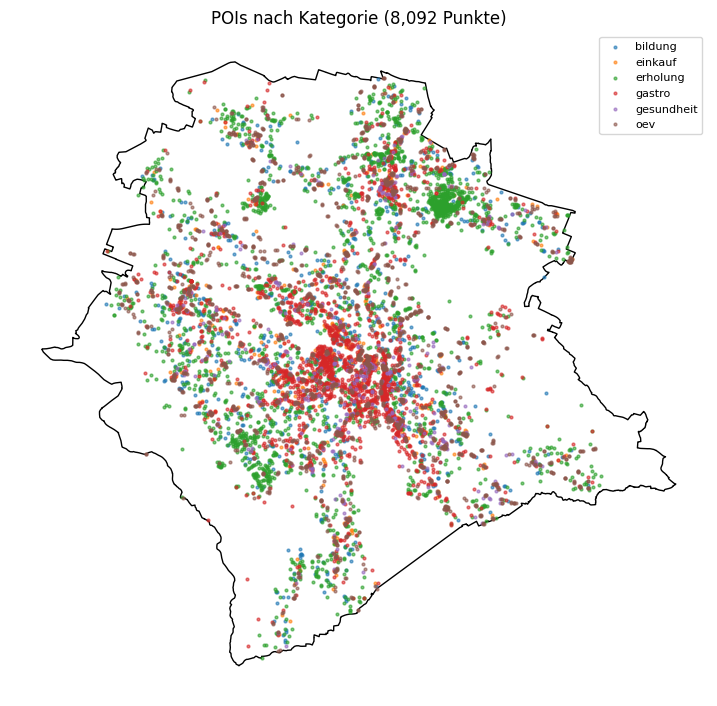

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 9))
boundary.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
for cat, grp in pois.groupby('category'):
    grp.plot(ax=ax, markersize=4, alpha=0.6, label=cat)
ax.legend(loc='upper right', fontsize=8)
ax.set_title(f'POIs nach Kategorie ({len(pois):,} Punkte)', fontsize=12)
ax.set_axis_off();

## 5. Zusammenfassung

- ✅ Stadtgrenze in `data/processed/zh_boundary.gpkg`
- ✅ POIs in `data/processed/zh_pois.gpkg` (Layer pro Kategorie + Layer `all`)

Weiter mit `02_streetnet_statpop.ipynb`.